In [1]:
import os
import torch
import pandas as pd
import wandb
import time
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification

INPUT_PATH = "/scratch/usr/nimtsspi/datasets/TG"
OUTPUT_PATH = "/scratch/usr/nimtsspi/datasets/TG"

/home/nimtsspi/micromamba/envs/tk_ma/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Summary of weak labels
## TG Unified 

In [2]:
tasks = ["hate","lexbias", "sentiment"] #gender
# Init target df
df = pd.read_parquet(f"{INPUT_PATH}/labels/TG_gender.parquet")
for task in tasks:
    path = f"{INPUT_PATH}/labels/TG_{task}.parquet"
    temp_df = pd.read_parquet(path)
    df = pd.merge(df, temp_df, on="message_id", how="inner")


In [3]:
tg_df = pd.read_parquet(f"{INPUT_PATH}/TG_unified.parquet")
tg_df.head()

,channel_id,message,topic,message_id,char_len
0,1150106827,Not Glory crying about her mom taking away her...,Religion,dbf24d19-7707-4a68-b67d-b42ed3bb6a5e,75
1,1150106827,LMFAO,Religion,b774cefe-c1ce-430b-9dfa-a9f043fce69d,5
2,1150106827,"Oh boy, looks like all Mercy lhemeson ( Glory'...",Religion,728e869e-08cc-4e17-8fbe-e72c09a4826e,138
3,1150106827,When glorilla tries to say it's not a victim. ...,Religion,2a695885-7d21-4816-9d8d-e3f7ca6bbe63,64
4,1150106827,Glory fucking a plunger cause no men wants her...,Religion,d11015b3-418a-40aa-ba5f-ca1dcc41f975,70


In [4]:
df = pd.merge(df, tg_df, how="inner", on="message_id")
df.head()

,message_id,gender,hate,lexbias,senti,channel_id,message,topic,char_len
0,dbf24d19-7707-4a68-b67d-b42ed3bb6a5e,False,normal,biased,negative,1150106827,Not Glory crying about her mom taking away her...,Religion,75
1,b774cefe-c1ce-430b-9dfa-a9f043fce69d,False,normal,neutral,neutral,1150106827,LMFAO,Religion,5
2,728e869e-08cc-4e17-8fbe-e72c09a4826e,False,normal,biased,positive,1150106827,"Oh boy, looks like all Mercy lhemeson ( Glory'...",Religion,138
3,2a695885-7d21-4816-9d8d-e3f7ca6bbe63,False,normal,biased,negative,1150106827,When glorilla tries to say it's not a victim. ...,Religion,64
4,d11015b3-418a-40aa-ba5f-ca1dcc41f975,True,offensive,biased,negative,1150106827,Glory fucking a plunger cause no men wants her...,Religion,70


In [5]:
# Store TG-weak-label-all
df.to_parquet(f"{OUTPUT_PATH}/TG-weak-label-all.parquet")

## Aggregate shares of labeled messages

In [6]:
# Function
def bar_chart(counts, task):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=counts, x="topic", y="percentage", hue=task)

    plt.title(f"Message Percentage by {task} and topic")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Topic")
    plt.legend(title=task)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

def pie_chart(df, label):
    # Show distribution
    counts = df[label].value_counts()
    print(counts)
    # Create pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    plt.title(f"Distribution of {label}")
    plt.axis('equal') 
    # Save figure
    #plt.savefig(f"src/{label}_dist.png")
    plt.show()
    plt.close()

def share_of_labels(df, task):

    # Make pie chart
    pie_chart(df, label=task)

    # Tabular distribution by topic
    counts = df.groupby(["topic", task]).agg(count=("message_id", "count"))
    counts["percentage"] = (counts["count"] / counts.groupby(level=0)["count"].transform("sum") * 100).round(2)
    print(counts)

    # Make Bar Plot
    bar_chart(counts, task)


gender
False    16794904
True       781130
Name: count, dtype: int64


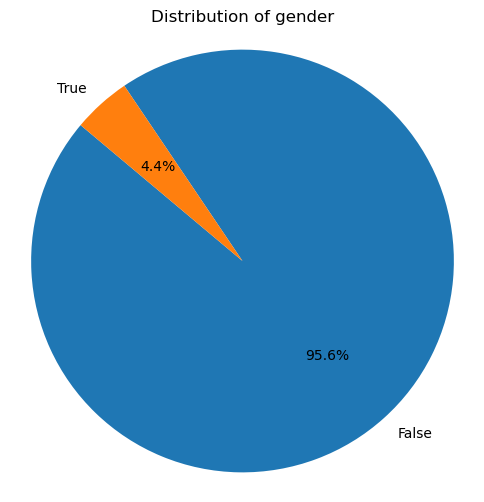

                                  count  percentage
topic                   gender                     
Carding                 False    786614       98.31
                        True      13484        1.69
Covid                   False   1158707       96.34
                        True      43980        3.66
Crypto                  False    882860       98.93
                        True       9552        1.07
Entertainment           False   1905219       94.81
                        True     104232        5.19
Extremists and radicals False    353099       95.13
                        True      18069        4.87
Indian edu              False    676922       98.14
                        True      12802        1.86
Porn                    False    498780       89.77
                        True      56814       10.23
Religion                False   3682552       92.60
                        True     294411        7.40
Social                  False    278301       94.35
            

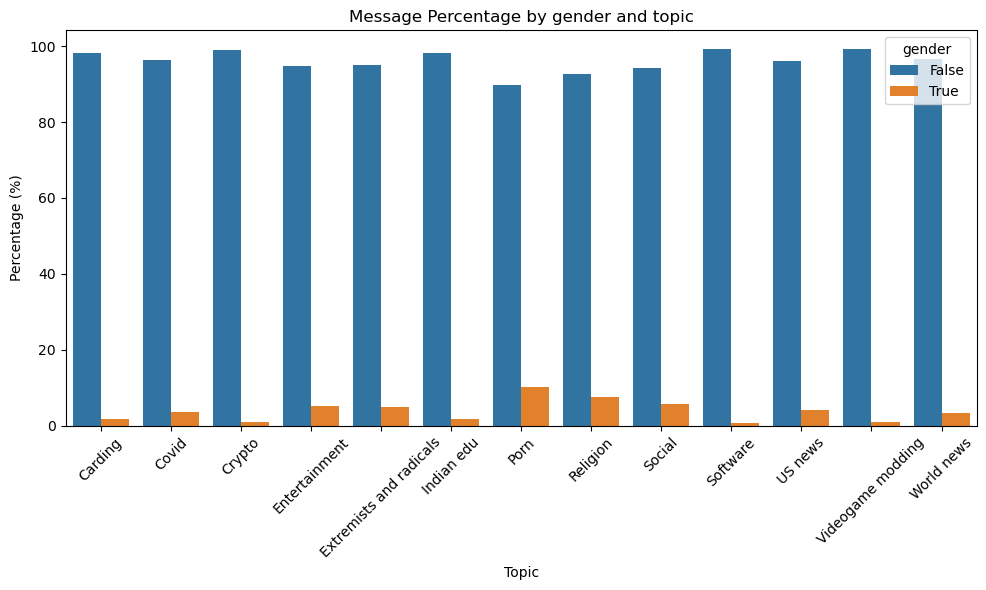

In [7]:
# Gender
share_of_labels(df, task="gender")

hate
normal         17356685
offensive        179507
hate speech       39842
Name: count, dtype: int64


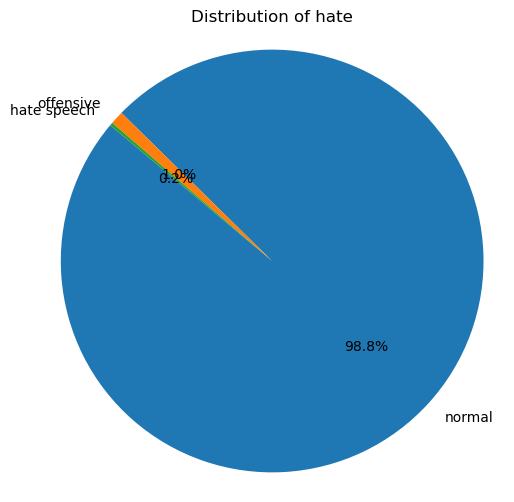

                                       count  percentage
topic                   hate                            
Carding                 hate speech      303        0.04
                        normal        797956       99.73
                        offensive       1839        0.23
Covid                   hate speech     2389        0.20
                        normal       1186194       98.63
                        offensive      14104        1.17
Crypto                  hate speech      687        0.08
                        normal        888164       99.52
                        offensive       3561        0.40
Entertainment           hate speech     1983        0.10
                        normal       1998492       99.45
                        offensive       8976        0.45
Extremists and radicals hate speech     7758        2.09
                        normal        344769       92.89
                        offensive      18641        5.02
Indian edu              hate sp

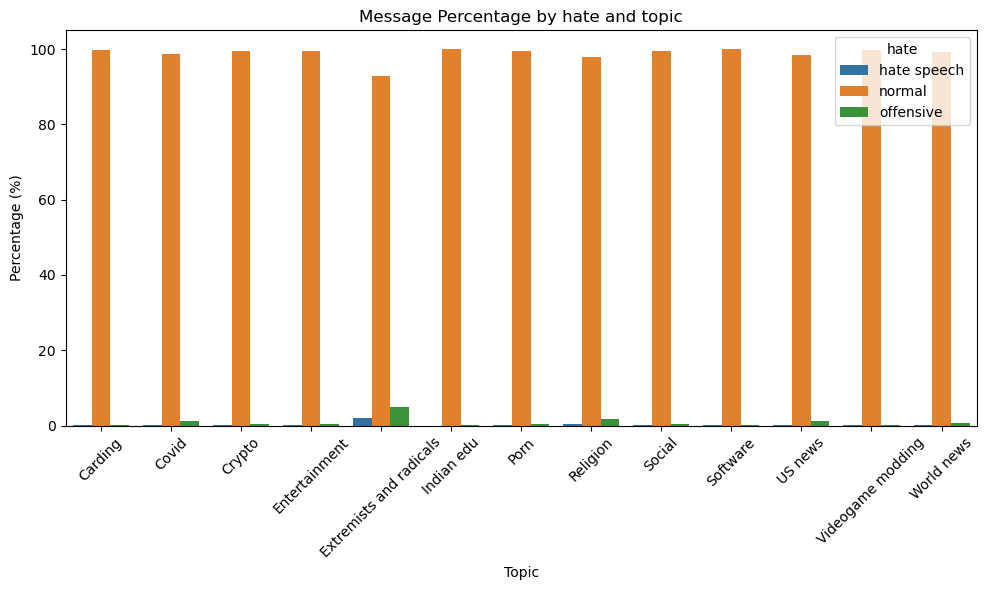

In [8]:
# Hatespeech
share_of_labels(df, task="hate")

senti
neutral     10909786
negative     3409966
positive     3256282
Name: count, dtype: int64


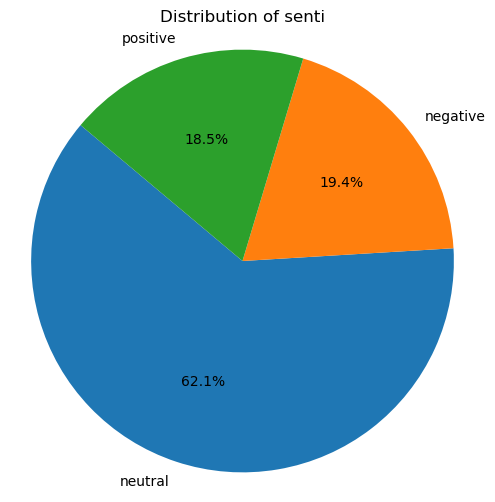

                                    count  percentage
topic                   senti                        
Carding                 negative    37914        4.74
                        neutral    525840       65.72
                        positive   236344       29.54
Covid                   negative   336990       28.02
                        neutral    678371       56.40
                        positive   187326       15.58
Crypto                  negative    73072        8.19
                        neutral    609473       68.30
                        positive   209867       23.52
Entertainment           negative   123498        6.15
                        neutral   1490489       74.17
                        positive   395464       19.68
Extremists and radicals negative   144518       38.94
                        neutral    180791       48.71
                        positive    45859       12.36
Indian edu              negative    27105        3.93
                        neut

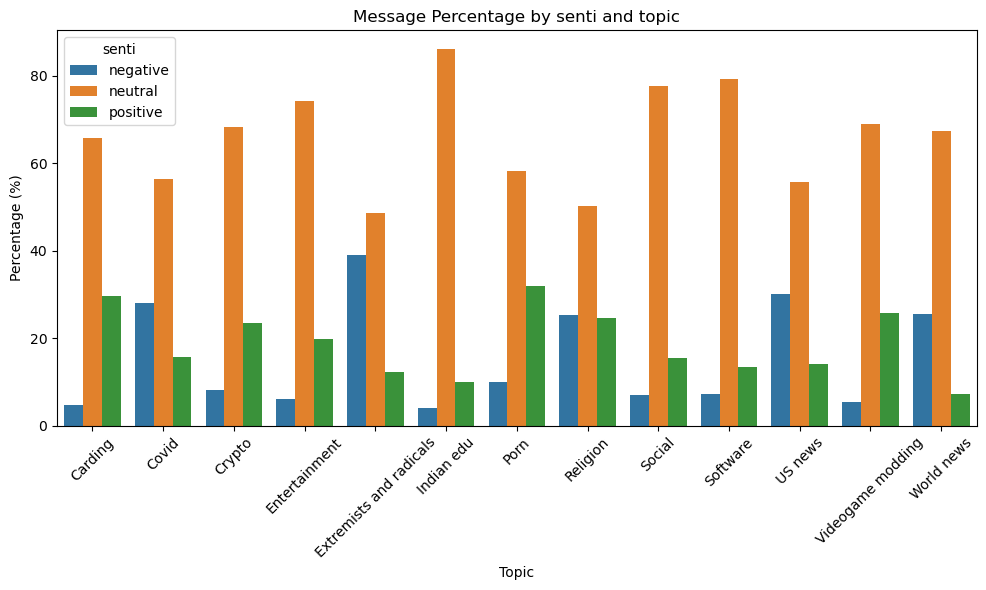

In [9]:
# Sentiment
share_of_labels(df, task="senti")

lexbias
neutral    11419626
biased      6156408
Name: count, dtype: int64


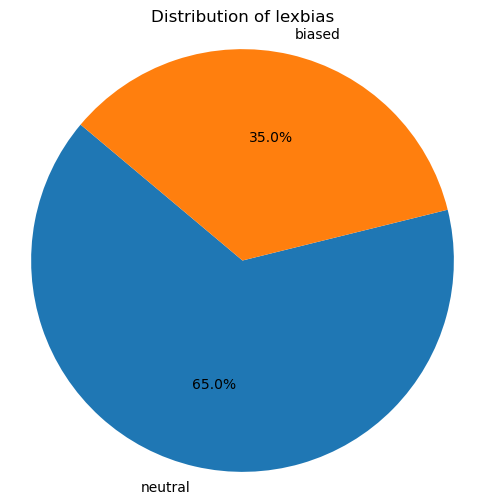

                                   count  percentage
topic                   lexbias                     
Carding                 biased    223069       27.88
                        neutral   577029       72.12
Covid                   biased    494548       41.12
                        neutral   708139       58.88
Crypto                  biased    151962       17.03
                        neutral   740450       82.97
Entertainment           biased    477073       23.74
                        neutral  1532378       76.26
Extremists and radicals biased    214052       57.67
                        neutral   157116       42.33
Indian edu              biased     99511       14.43
                        neutral   590213       85.57
Porn                    biased    217152       39.08
                        neutral   338442       60.92
Religion                biased   1824752       45.88
                        neutral  2152211       54.12
Social                  biased     74546      

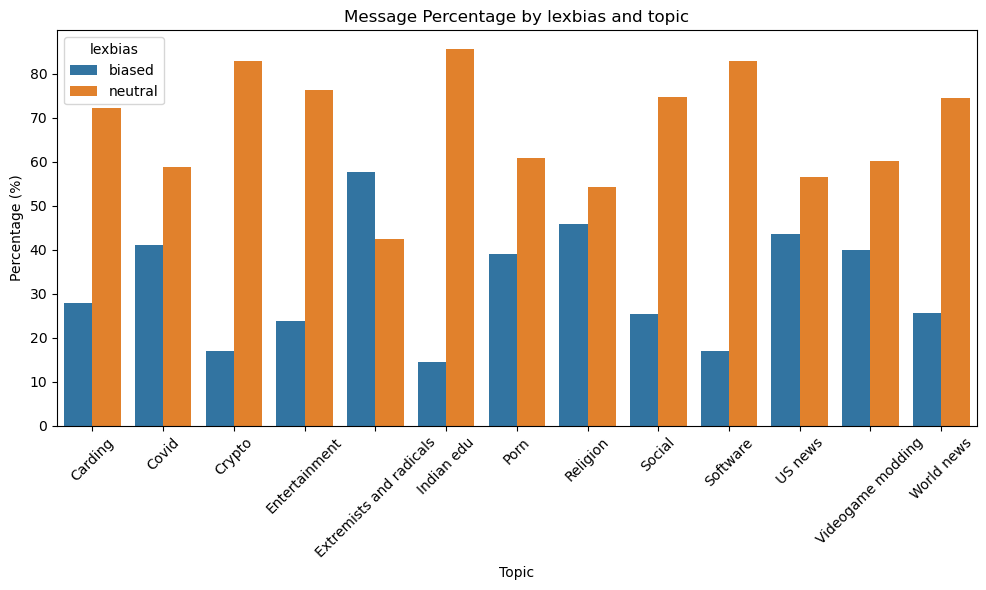

In [10]:
# Lexbias
share_of_labels(df, task="lexbias")

## TG Topic Augmented

In [17]:
tasks = ["hate","lexbias", "sentiment"] #gender
# Init target df
df = pd.read_parquet(f"{INPUT_PATH}/labels/TG_gender.parquet")
for task in tasks:
    path = f"{INPUT_PATH}/labels/TG_{task}.parquet"
    temp_df = pd.read_parquet(path)
    df = pd.merge(df, temp_df, on="message_id", how="inner")

tg_topic_augmented_df = pd.read_parquet(f"{INPUT_PATH}/TG_topic_augmented.parquet")
df = pd.merge(df, tg_topic_augmented_df, how="inner", on="message_id")
df.head()

,message_id,gender,hate,lexbias,senti,channel_id,message,topic,char_len
0,dbf24d19-7707-4a68-b67d-b42ed3bb6a5e,False,normal,biased,negative,1150106827,Not Glory crying about her mom taking away her...,Religion,75
1,b774cefe-c1ce-430b-9dfa-a9f043fce69d,False,normal,neutral,neutral,1150106827,LMFAO,Religion,5
2,728e869e-08cc-4e17-8fbe-e72c09a4826e,False,normal,biased,positive,1150106827,"Oh boy, looks like all Mercy lhemeson ( Glory'...",Religion,138
3,2a695885-7d21-4816-9d8d-e3f7ca6bbe63,False,normal,biased,negative,1150106827,When glorilla tries to say it's not a victim. ...,Religion,64
4,d11015b3-418a-40aa-ba5f-ca1dcc41f975,True,offensive,biased,negative,1150106827,Glory fucking a plunger cause no men wants her...,Religion,70


In [18]:
# Store TG-weak-label-core
df.to_parquet(f"{OUTPUT_PATH}/TG-weak-label-core.parquet")

gender
False    10458234
True       571144
Name: count, dtype: int64


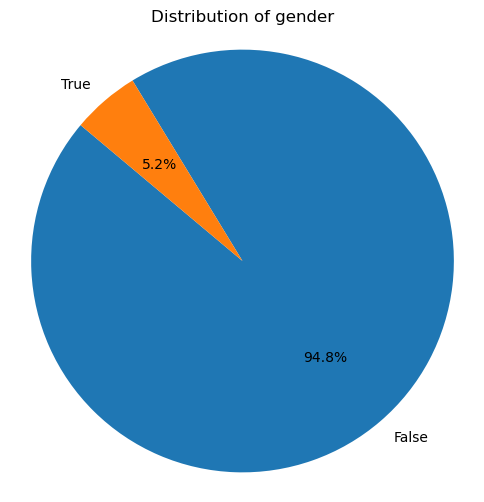

                                  count  percentage
topic                   gender                     
Covid                   False   1158707       96.34
                        True      43980        3.66
Extremists and radicals False    353099       95.13
                        True      18069        4.87
Religion                False   3682552       92.60
                        True     294411        7.40
Social                  False    278301       94.35
                        True      16659        5.65
US news                 False   3372141       95.97
                        True     141648        4.03
World news              False   1613434       96.62
                        True      56377        3.38


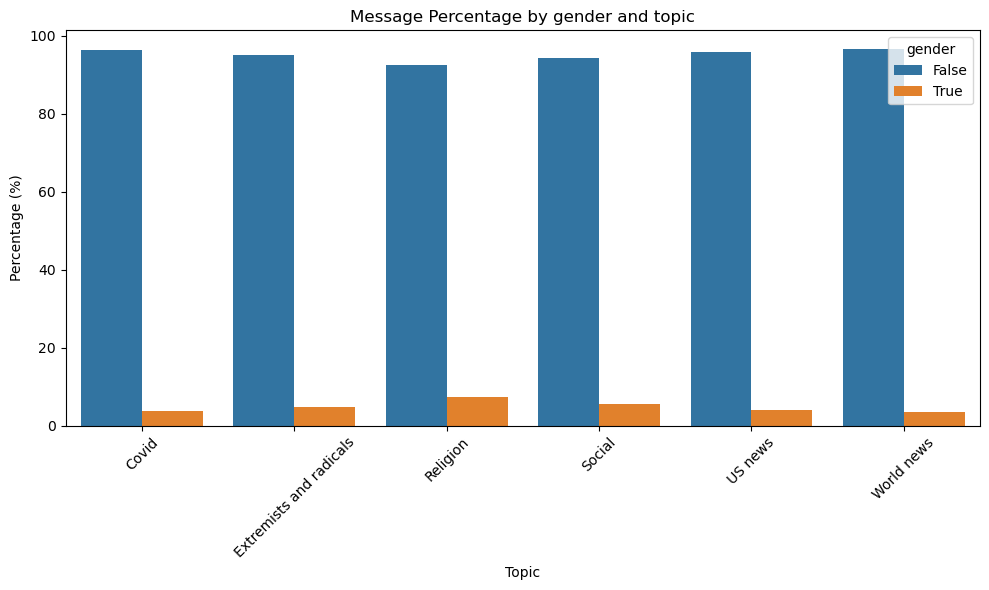

In [13]:
# Gender
share_of_labels(df, task="gender")

hate
normal         10833076
offensive        160340
hate speech       35962
Name: count, dtype: int64


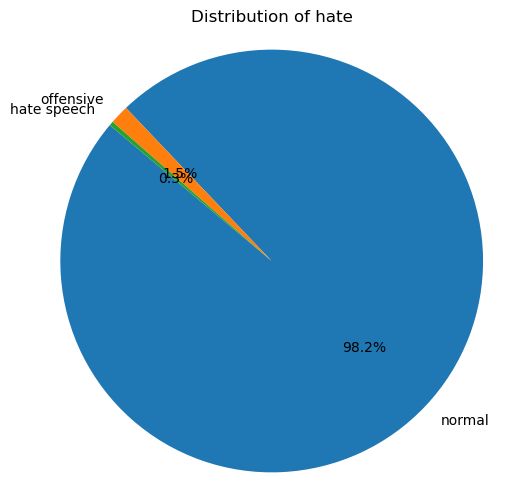

                                       count  percentage
topic                   hate                            
Covid                   hate speech     2389        0.20
                        normal       1186194       98.63
                        offensive      14104        1.17
Extremists and radicals hate speech     7758        2.09
                        normal        344769       92.89
                        offensive      18641        5.02
Religion                hate speech    14998        0.38
                        normal       3891135       97.84
                        offensive      70830        1.78
Social                  hate speech      307        0.10
                        normal        293501       99.51
                        offensive       1152        0.39
US news                 hate speech     7611        0.22
                        normal       3461549       98.51
                        offensive      44629        1.27
World news              hate sp

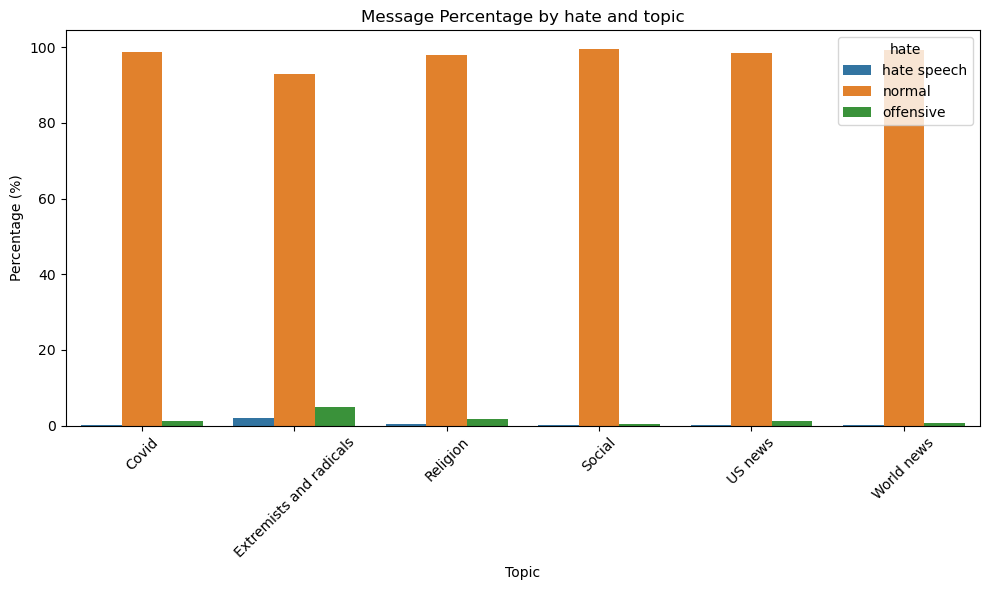

In [14]:
# Hatespeech
share_of_labels(df, task="hate")

senti
neutral     6166552
negative    2989426
positive    1873400
Name: count, dtype: int64


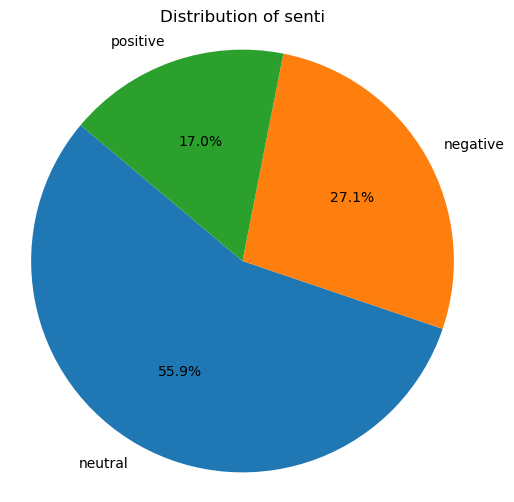

                                    count  percentage
topic                   senti                        
Covid                   negative   336990       28.02
                        neutral    678371       56.40
                        positive   187326       15.58
Extremists and radicals negative   144518       38.94
                        neutral    180791       48.71
                        positive    45859       12.36
Religion                negative  1002362       25.20
                        neutral   1997060       50.22
                        positive   977541       24.58
Social                  negative    20754        7.04
                        neutral    228749       77.55
                        positive    45457       15.41
US news                 negative  1060112       30.17
                        neutral   1955659       55.66
                        positive   498018       14.17
World news              negative   424690       25.43
                        neut

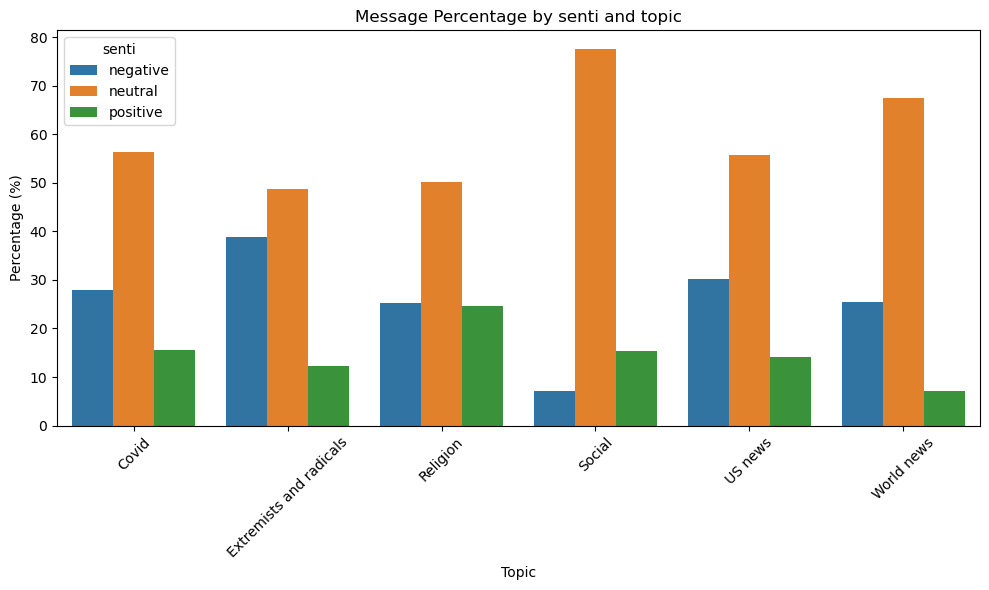

In [15]:
# Sentiment
share_of_labels(df, task="senti")

lexbias
neutral    6463010
biased     4566368
Name: count, dtype: int64


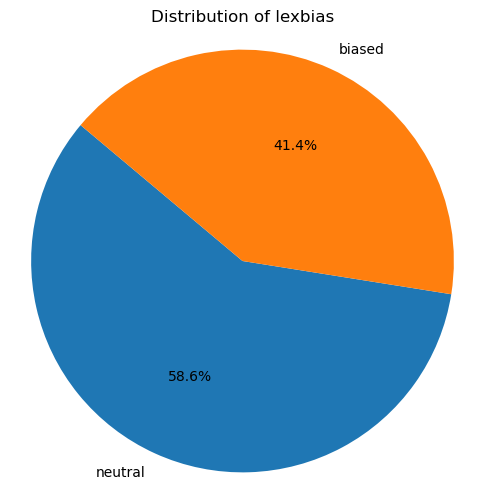

                                   count  percentage
topic                   lexbias                     
Covid                   biased    494548       41.12
                        neutral   708139       58.88
Extremists and radicals biased    214052       57.67
                        neutral   157116       42.33
Religion                biased   1824752       45.88
                        neutral  2152211       54.12
Social                  biased     74546       25.27
                        neutral   220414       74.73
US news                 biased   1532074       43.60
                        neutral  1981715       56.40
World news              biased    426396       25.54
                        neutral  1243415       74.46


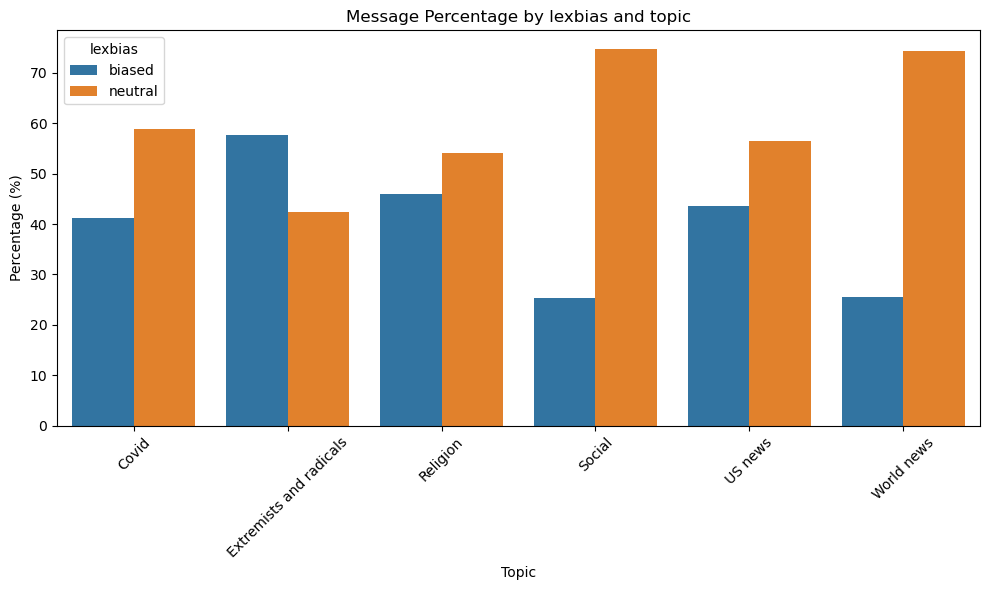

In [16]:
# Lexbias
share_of_labels(df, task="lexbias")